# 1.Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2.Load Dataset

In [6]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 83 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

# 3.Checking missing values

In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

# 4.Handling missing values

In [8]:
df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
df['MasVnrArea'].fillna(df['MasVnrArea'].mean(), inplace=True)
df['GarageType'].fillna(df['GarageType'].mode()[0], inplace=True)

C:\Users\MADHU\AppData\Local\Temp\ipykernel_20980\2293030.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LotFrontage'].fillna(df['LotFrontage'].median(), inplace=True)
C:\Users\MADHU\AppData\Local\Temp\ipykernel_20980\2293030.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

# 5.Feature Engineering

In [9]:
# Total Area
df["TotalArea"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

In [10]:
# House Age
current_year = 2026
df["HouseAge"] = current_year - df["YearBuilt"]

# 6.Selecting Features

In [11]:
features = ["OverallQual","GrLivArea","GarageCars","TotalArea","HouseAge"]
X = df[features]
y = df["SalePrice"]

# 7.Train Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8.Train Linear Regression Model

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

# 9.Prediction

In [15]:
y_pred = model.predict(X_test)
y_pred

array([142138.72919737, 294399.8126888 , 122405.11256182, 180266.73936715,
       288414.9389855 ,  56661.30927713, 207330.10758031, 175850.67253141,
        56042.85659808, 129180.444967  , 166923.21050306, 108808.46101213,
        89649.34793966, 224827.14887273, 195928.30108858, 114396.75463862,
       216943.75470382, 122826.07871608, 124899.24700211, 220148.09248343,
       173071.39861319, 230369.25472705, 182246.89304731, 109964.48235538,
       215991.06812851, 176455.56940107, 211690.49594938,  97711.0278428 ,
       190809.22742482, 212274.59482682, 114916.12377102, 251744.45195876,
       202448.78456713,  90746.39614913, 268561.03550418, 148045.45952282,
       162685.51557952, 227069.23381415, 300981.32225536,  83786.58002204,
       138410.8953505 , 235800.04979694, 115645.09020141, 299730.24895956,
       130443.50497563, 171516.72723476, 110651.64263766, 114471.17734418,
       345037.09312037, 138026.32388924, 109166.4937369 , 198903.25462236,
       117417.04095694, 3

# 10.Evaluate Model

In [16]:
# RSME
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 39646.59040151373


In [17]:
# r-squared score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7950736268566299


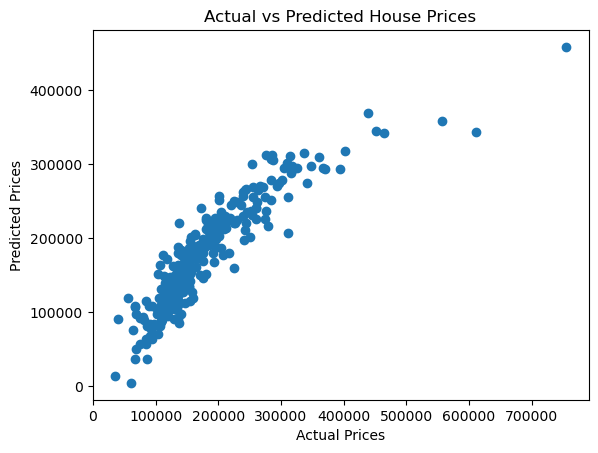

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [20]:
import pickle
pickle.dump(model, open("house_price_model.pkl", "wb"))